# Experiment 3.2 — Nonlinear temporal interaction probe

Analysis-only notebook. Training is performed by the Slurm array in `scripts/bash_script/SNN_Bash/run_exp_3_2_cpu_array.bash`; this notebook only reads finalized artifacts.

Primary question: **Do nonlinear interactions between adjacent temporal segments contain discriminative information beyond a position-aware Linear decoder?**

Primary representation: **Fixed250**. Primary effect: `Transition - Linear`. Mechanism control: `Transition - Local`.

In [2]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt

def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / 'snn').is_dir() and (candidate / 'notebooks').is_dir():
            return candidate
    raise FileNotFoundError('Could not locate writingRing repository root')

REPO_ROOT = find_repo_root()
ROOT = REPO_ROOT / 'notebooks/artifacts/experiment_3_2_nonlinear_temporal_interaction/low_rank_residual_v1'
RESULTS = pd.read_csv(ROOT / 'experiment_3_2_results.csv')
DELTAS = pd.read_csv(ROOT / 'experiment_3_2_paired_deltas.csv')
SUMMARY = pd.read_csv(ROOT / 'experiment_3_2_summary.csv')
MECHANISM = pd.read_csv(ROOT / 'experiment_3_2_mechanism_summary.csv')
REPRO = pd.read_csv(ROOT / 'experiment_3_2_baseline_reproduction.csv')
PARAMS = pd.read_csv(ROOT / 'experiment_3_2_parameter_counts.csv')
print('Artifact root:', ROOT)


Artifact root: /home/zhaolongwei_umass_edu/projects/writingRing/notebooks/artifacts/experiment_3_2_nonlinear_temporal_interaction/low_rank_residual_v1


## 1. Baseline reproduction gate

Experiment 3.2 recomputes the 1.3.3 Linear baseline on every split. The finalizer already rejects an absolute per-split BA drift greater than 0.01; inspect the exact paired differences here.

In [3]:
display(REPRO.sort_values(['representation', 'split_seed']).reset_index(drop=True))
print('max |difference| =', REPRO.abs_difference.max())


,representation,split_seed,exp32_linear_test_ba,exp133_linear_test_ba,difference,abs_difference
0,fixed250,11,0.683184,0.683184,0.0,0.0
1,fixed250,23,0.537563,0.537563,0.0,0.0
2,fixed250,37,0.610290,0.610290,0.0,0.0
3,fixed250,53,0.466443,0.466443,0.0,0.0
4,fixed250,71,0.626929,0.626929,0.0,0.0
5,fixed500,11,0.647699,0.647699,0.0,0.0
6,fixed500,23,0.571126,0.571126,0.0,0.0
7,fixed500,37,0.588104,0.588104,0.0,0.0
8,fixed500,53,0.633159,0.633159,0.0,0.0
9,fixed500,71,0.578741,0.578741,0.0,0.0


max |difference| = 0.0


## 2. Main decoder summary

In [4]:
display(SUMMARY.sort_values(['representation', 'decoder']).reset_index(drop=True))
display(PARAMS.sort_values(['representation', 'decoder']).reset_index(drop=True))


,representation,decoder,n_splits,mean_test_ba,sd_test_ba,mean_test_macro_f1,mean_delta_vs_linear,sd_delta_vs_linear,median_delta_vs_linear,min_delta_vs_linear,max_delta_vs_linear,improved_splits,n_trainable_params
0,fixed250,local,5,0.600837,0.068709,0.600370,0.015955,0.026396,0.006638,-0.010110,0.047640,3,3552
1,fixed250,local_transition,5,0.611971,0.066188,0.607977,0.027089,0.024411,0.020833,0.008034,0.069736,5,7392
2,fixed250,transition,5,0.603778,0.069323,0.602048,0.018897,0.021436,0.013317,-0.001959,0.055216,4,3840
3,fixed500,local,5,0.603238,0.030159,0.596441,-0.000528,0.007793,-0.004630,-0.006410,0.012153,2,2016
4,fixed500,local_transition,5,0.623394,0.033317,0.616006,0.019628,0.024726,0.028622,-0.019765,0.044964,4,4320
5,fixed500,transition,5,0.619025,0.038410,0.611058,0.015259,0.030072,0.016222,-0.020493,0.060934,3,2304
6,relative10,local,5,0.714429,0.070045,0.715845,-0.000310,0.022779,0.001050,-0.033890,0.030206,3,2400
7,relative10,local_transition,5,0.723351,0.069875,0.723225,0.008612,0.023055,0.006944,-0.018687,0.043144,3,5088
8,relative10,transition,5,0.716256,0.083216,0.716494,0.001516,0.016353,0.000000,-0.016144,0.022338,2,2688


,representation,decoder,n_trainable_params
0,fixed250,local,3552
1,fixed250,local_transition,7392
2,fixed250,transition,3840
3,fixed500,local,2016
4,fixed500,local_transition,4320
5,fixed500,transition,2304
6,relative10,local,2400
7,relative10,local_transition,5088
8,relative10,transition,2688


## 3. Paired Linear → Transition comparison

Each line is one user-disjoint split. This exposes whether the mean gain is consistent or driven by one split.

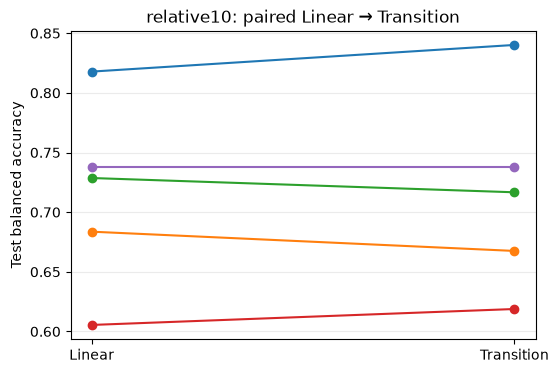

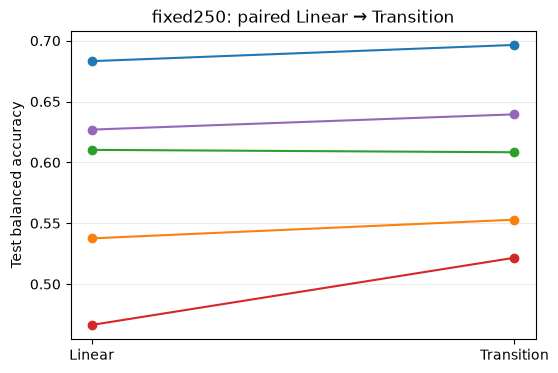

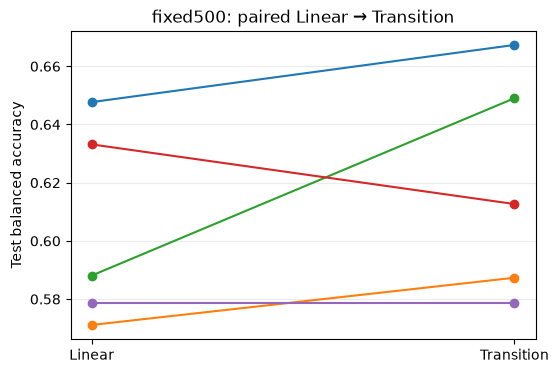

In [5]:
for representation in ('relative10', 'fixed250', 'fixed500'):
    frame = DELTAS[DELTAS.representation == representation].sort_values('split_seed')
    fig, ax = plt.subplots(figsize=(6, 4))
    for row in frame.itertuples(index=False):
        ax.plot([0, 1], [row.linear_test_ba, row.transition_test_ba], marker='o')
    ax.set_xticks([0, 1], ['Linear', 'Transition'])
    ax.set_ylabel('Test balanced accuracy')
    ax.set_title(f'{representation}: paired Linear → Transition')
    ax.grid(axis='y', alpha=0.25)
    plt.show()


## 4. Paired gains vs Linear

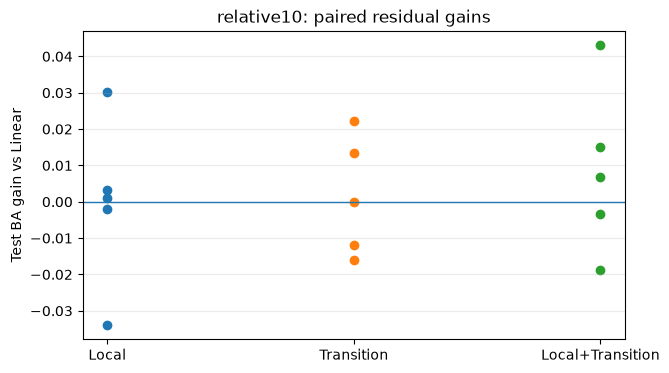

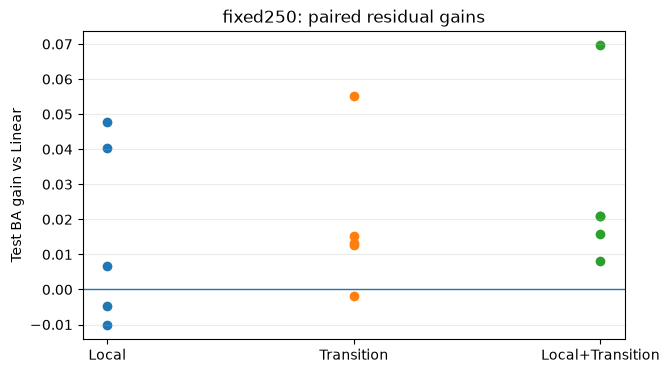

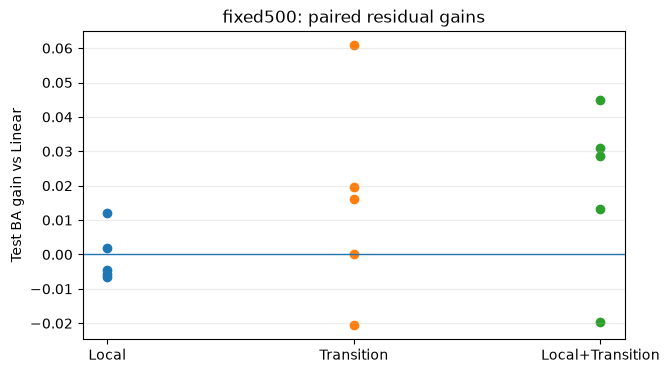

In [6]:
gain_columns = {
    'Local': 'local_minus_linear',
    'Transition': 'transition_minus_linear',
    'Local+Transition': 'local_transition_minus_linear',
}
for representation in ('relative10', 'fixed250', 'fixed500'):
    frame = DELTAS[DELTAS.representation == representation]
    fig, ax = plt.subplots(figsize=(7, 4))
    for x_index, (label, column) in enumerate(gain_columns.items()):
        values = frame[column].to_numpy()
        ax.scatter([x_index] * len(values), values)
    ax.axhline(0.0, linewidth=1)
    ax.set_xticks(range(len(gain_columns)), list(gain_columns))
    ax.set_ylabel('Test BA gain vs Linear')
    ax.set_title(f'{representation}: paired residual gains')
    ax.grid(axis='y', alpha=0.25)
    plt.show()


## 5. Mechanism control: Transition − Local

Positive values support adjacent cross-bin interaction beyond generic within-bin nonlinearity.

,representation,mean_transition_minus_local,sd_transition_minus_local,median_transition_minus_local,transition_better_splits
0,fixed250,0.002942,0.026073,0.008721,4
1,fixed500,0.015787,0.032853,0.014418,3
2,relative10,0.001827,0.018146,-0.001050,2


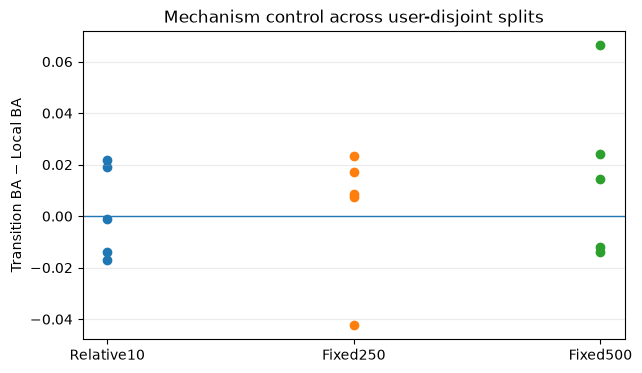

In [7]:
display(MECHANISM.sort_values('representation').reset_index(drop=True))
fig, ax = plt.subplots(figsize=(7, 4))
for x_index, representation in enumerate(('relative10', 'fixed250', 'fixed500')):
    values = DELTAS.loc[DELTAS.representation == representation, 'transition_minus_local'].to_numpy()
    ax.scatter([x_index] * len(values), values)
ax.axhline(0.0, linewidth=1)
ax.set_xticks([0, 1, 2], ['Relative10', 'Fixed250', 'Fixed500'])
ax.set_ylabel('Transition BA − Local BA')
ax.set_title('Mechanism control across user-disjoint splits')
ax.grid(axis='y', alpha=0.25)
plt.show()


## Interpretation guardrails

- Treat `Transition > Linear` plus `Transition > Local` on Fixed250 as the primary temporal-composition evidence.
- If Local and Transition improve similarly, conclude generic nonlinearity helps; do not claim temporal composition specifically.
- Cross-representation gain differences are secondary because bin counts and trainable parameter counts differ.
- Report all five paired split values, not only mean ± SD.

,Readout,Representation,Test BA (mean ± SD)
0,Linear,Fixed250,58.49 ± 8.42%
1,Linear,Fixed500,60.38 ± 3.44%
2,Linear,Relative10,71.47 ± 7.79%
3,Linear + Local,Fixed250,60.08 ± 6.87%
4,Linear + Local,Fixed500,60.32 ± 3.02%
5,Linear + Local,Relative10,71.44 ± 7.00%
6,Linear + Transition,Fixed250,60.38 ± 6.93%
7,Linear + Transition,Fixed500,61.90 ± 3.84%
8,Linear + Transition,Relative10,71.63 ± 8.32%
9,Linear + Local + Transition,Fixed250,61.20 ± 6.62%


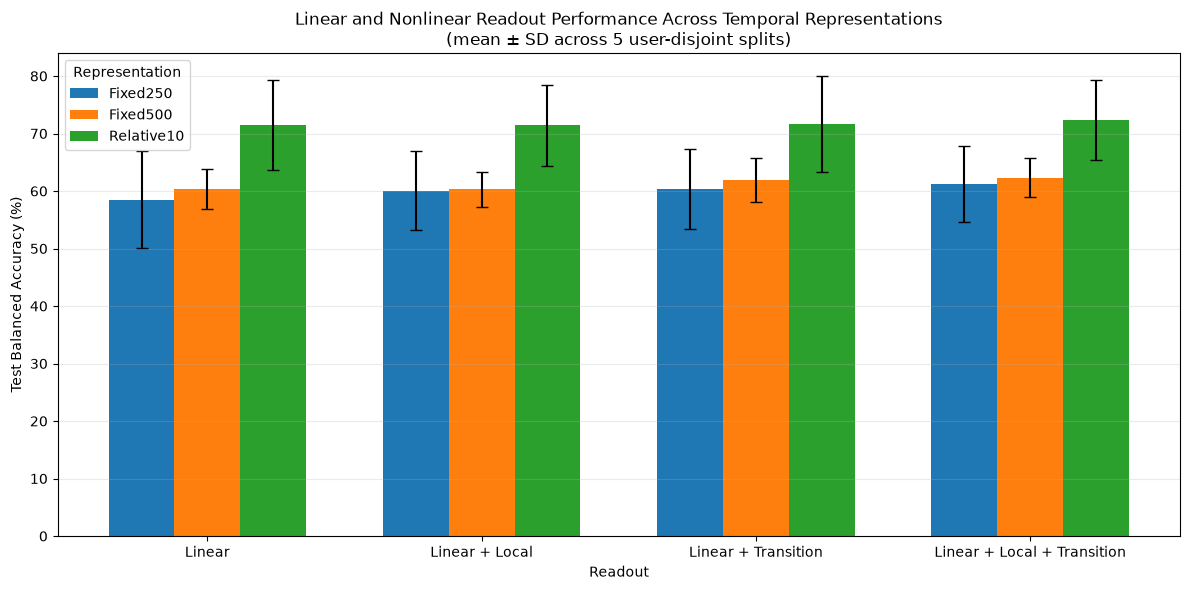

In [12]:
# Mean ± SD test Balanced Accuracy for:
# Linear,
# Linear + Local,
# Linear + Transition,
# Linear + Local + Transition
#
# across Fixed250, Fixed500, and Relative10.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


representation_order = [
    "fixed250",
    "fixed500",
    "relative10",
]

branch_order = [
    "linear",
    "linear_local",
    "linear_transition",
    "linear_local_transition",
]

representation_labels = {
    "fixed250": "Fixed250",
    "fixed500": "Fixed500",
    "relative10": "Relative10",
}

branch_labels = {
    "linear": "Linear",
    "linear_local": "Linear + Local",
    "linear_transition": "Linear + Transition",
    "linear_local_transition": "Linear + Local + Transition",
}


# ================================================================
# 1. Linear baseline: compute mean ± SD across the 5 paired splits
# ================================================================

linear_df = (
    REPRO[
        REPRO["representation"].isin(representation_order)
    ]
    .groupby("representation", as_index=False)
    .agg(
        mean_test_ba=("exp32_linear_test_ba", "mean"),
        sd_test_ba=("exp32_linear_test_ba", "std"),
    )
)

linear_df["branch"] = "linear"


# ================================================================
# 2. Nonlinear residual branches
# ================================================================

decoder_to_branch = {
    "local": "linear_local",
    "transition": "linear_transition",
    "local_transition": "linear_local_transition",
}

nonlinear_df = (
    SUMMARY[
        SUMMARY["representation"].isin(representation_order)
        & SUMMARY["decoder"].isin(decoder_to_branch.keys())
    ][
        [
            "representation",
            "decoder",
            "mean_test_ba",
            "sd_test_ba",
        ]
    ]
    .copy()
)

nonlinear_df["branch"] = nonlinear_df["decoder"].map(
    decoder_to_branch
)

nonlinear_df = nonlinear_df.drop(columns="decoder")


# ================================================================
# 3. Combine Linear + nonlinear branches
# ================================================================

plot_df = pd.concat(
    [
        linear_df[
            [
                "representation",
                "branch",
                "mean_test_ba",
                "sd_test_ba",
            ]
        ],
        nonlinear_df[
            [
                "representation",
                "branch",
                "mean_test_ba",
                "sd_test_ba",
            ]
        ],
    ],
    ignore_index=True,
)

plot_df["representation"] = pd.Categorical(
    plot_df["representation"],
    categories=representation_order,
    ordered=True,
)

plot_df["branch"] = pd.Categorical(
    plot_df["branch"],
    categories=branch_order,
    ordered=True,
)

plot_df = (
    plot_df
    .sort_values(["branch", "representation"])
    .reset_index(drop=True)
)


# ================================================================
# 4. Display Mean ± SD table
# ================================================================

table = plot_df.copy()

table["Readout"] = table["branch"].map(branch_labels)

table["Representation"] = table["representation"].map(
    representation_labels
)

table["Test BA (mean ± SD)"] = table.apply(
    lambda row: (
        f"{100 * row['mean_test_ba']:.2f} ± "
        f"{100 * row['sd_test_ba']:.2f}%"
    ),
    axis=1,
)

display(
    table[
        [
            "Readout",
            "Representation",
            "Test BA (mean ± SD)",
        ]
    ].reset_index(drop=True)
)


# ================================================================
# 5. Grouped bar plot
# ================================================================

fig, ax = plt.subplots(figsize=(12.0, 6.0))

x = np.arange(len(branch_order))

n_repr = len(representation_order)
bar_width = 0.24

offsets = (
    np.arange(n_repr)
    - (n_repr - 1) / 2
) * bar_width


for offset, representation in zip(
    offsets,
    representation_order,
):
    sub = (
        plot_df[
            plot_df["representation"] == representation
        ]
        .set_index("branch")
        .reindex(branch_order)
    )

    means = 100 * sub["mean_test_ba"].to_numpy()
    sds = 100 * sub["sd_test_ba"].to_numpy()

    ax.bar(
        x + offset,
        means,
        width=bar_width,
        yerr=sds,
        capsize=4,
        label=representation_labels[representation],
    )


ax.set_xticks(x)

ax.set_xticklabels(
    [branch_labels[b] for b in branch_order]
)

ax.set_ylabel("Test Balanced Accuracy (%)")

ax.set_xlabel("Readout")

ax.set_title(
    "Linear and Nonlinear Readout Performance Across Temporal Representations\n"
    "(mean ± SD across 5 user-disjoint splits)"
)

ax.legend(title="Representation")

ax.grid(
    axis="y",
    alpha=0.25,
)

fig.tight_layout()

plt.show()

,Decoder,Representation,"ΔBA vs Linear (mean ± SD, pp)"
0,Local,Fixed250,+1.60 ± 2.64
1,Local,Fixed500,-0.05 ± 0.78
2,Local,Relative10,-0.03 ± 2.28
3,Transition,Fixed250,+1.89 ± 2.14
4,Transition,Fixed500,+1.53 ± 3.01
5,Transition,Relative10,+0.15 ± 1.64
6,Local + Transition,Fixed250,+2.71 ± 2.44
7,Local + Transition,Fixed500,+1.96 ± 2.47
8,Local + Transition,Relative10,+0.86 ± 2.31


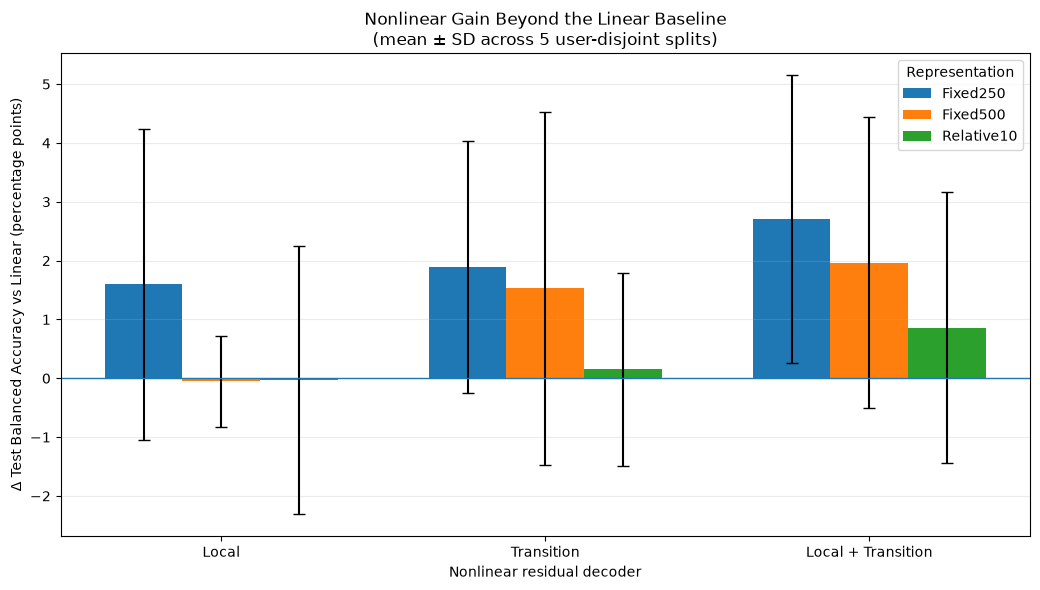

In [11]:
# Mean ± SD nonlinear gain over the Linear baseline
# ΔBA = BA(nonlinear residual) - BA(Linear)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

representation_order = ["fixed250", "fixed500", "relative10"]
decoder_order = ["local", "transition", "local_transition"]

representation_labels = {
    "fixed250": "Fixed250",
    "fixed500": "Fixed500",
    "relative10": "Relative10",
}

decoder_labels = {
    "local": "Local",
    "transition": "Transition",
    "local_transition": "Local + Transition",
}

# ------------------------------------------------------------------
# Select and order results
# ------------------------------------------------------------------
plot_df = (
    SUMMARY[
        SUMMARY["representation"].isin(representation_order)
        & SUMMARY["decoder"].isin(decoder_order)
    ]
    .copy()
)

plot_df["representation"] = pd.Categorical(
    plot_df["representation"],
    categories=representation_order,
    ordered=True,
)

plot_df["decoder"] = pd.Categorical(
    plot_df["decoder"],
    categories=decoder_order,
    ordered=True,
)

plot_df = (
    plot_df
    .sort_values(["decoder", "representation"])
    .reset_index(drop=True)
)

# ------------------------------------------------------------------
# Display ΔBA mean ± SD table
# ------------------------------------------------------------------
table = plot_df[
    [
        "decoder",
        "representation",
        "mean_delta_vs_linear",
        "sd_delta_vs_linear",
    ]
].copy()

table["Decoder"] = table["decoder"].map(decoder_labels)
table["Representation"] = table["representation"].map(
    representation_labels
)

table["ΔBA vs Linear (mean ± SD, pp)"] = table.apply(
    lambda row: (
        f"{100 * row['mean_delta_vs_linear']:+.2f} ± "
        f"{100 * row['sd_delta_vs_linear']:.2f}"
    ),
    axis=1,
)

display(
    table[
        [
            "Decoder",
            "Representation",
            "ΔBA vs Linear (mean ± SD, pp)",
        ]
    ].reset_index(drop=True)
)

# ------------------------------------------------------------------
# Grouped bar plot
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10.5, 6.0))

x = np.arange(len(decoder_order))
n_repr = len(representation_order)
bar_width = 0.24

offsets = (
    np.arange(n_repr) - (n_repr - 1) / 2
) * bar_width

for offset, representation in zip(
    offsets,
    representation_order,
):
    sub = (
        plot_df[
            plot_df["representation"] == representation
        ]
        .set_index("decoder")
        .reindex(decoder_order)
    )

    means = 100 * sub["mean_delta_vs_linear"].to_numpy()
    sds = 100 * sub["sd_delta_vs_linear"].to_numpy()

    ax.bar(
        x + offset,
        means,
        width=bar_width,
        yerr=sds,
        capsize=4,
        label=representation_labels[representation],
    )

ax.axhline(0.0, linewidth=1.0)

ax.set_xticks(x)
ax.set_xticklabels(
    [decoder_labels[d] for d in decoder_order]
)

ax.set_ylabel(
    "Δ Test Balanced Accuracy vs Linear (percentage points)"
)
ax.set_xlabel("Nonlinear residual decoder")

ax.set_title(
    "Nonlinear Gain Beyond the Linear Baseline\n"
    "(mean ± SD across 5 user-disjoint splits)"
)

ax.legend(title="Representation")
ax.grid(axis="y", alpha=0.25)

fig.tight_layout()
plt.show()